# D3 - Entrate comuni 2021-2025

Notebook di supporto al follow-up multi-anno su `siope-comuni`.

**Perimetro**
- anni: `2021-2025`
- livello: `COMUNE`
- base: `is_titolo_9 = false`
- focus: `Milano`, `Palermo`, `Catania`, con breakdown di `Altro` per `Milano` e `Firenze`

**Obiettivo**
- usare davvero il `cross_year` a 5 anni
- verificare se i segnali letti su `2023-2024` reggono anche nel `2025`
- entrare dentro `Altro` nei due casi dove il peso resta piu alto


In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

REPO_ROOT = Path.cwd().resolve().parents[2]
CROSS_PATH = REPO_ROOT / 'out' / 'data' / 'cross' / 'siope_comparto_2y' / 'siope_entrate_comuni_agg_labeled_multi_anno.parquet'

COMUNI_FOCUS = {
    'ROMA CAPITALE': 'Roma',
    'COMUNE DI MILANO': 'Milano',
    'COMUNE DI PALERMO': 'Palermo',
    'COMUNE DI CATANIA': 'Catania',
    'COMUNE DI FIRENZE': 'Firenze',
}

con = duckdb.connect()
assert CROSS_PATH.exists(), f'Manca il cross-year: {CROSS_PATH}'
print(CROSS_PATH)


C:\Users\gabry\OneDrive\Desktop\dataciviclab-workspace\siope-comuni\out\data\cross\siope_comparto_2y\siope_entrate_comuni_agg_labeled_multi_anno.parquet


## 1. Copertura 2021-2025

Prima verifico che il `cross_year` copra davvero tutti i cinque anni sul perimetro comuni.

In [2]:
copertura = con.execute(
    '''
    select anno, count(*) as righe, count(distinct codice_ente) as enti
    from read_parquet(?)
    where tipo_ente = 'COMUNE'
    group by 1
    order by 1
    ''',
    [str(CROSS_PATH)],
).df()

copertura

,anno,righe,enti
0,2021,369477,7903
1,2022,365973,7904
2,2023,354223,7524
3,2024,373008,7902
4,2025,372362,7896


## 2. Quota per macro-categoria nei casi chiave

Qui restringo il focus a tre casi utili per leggere il 2025:
- `Milano`, dove `Altro` pesa molto e la quota di imposte proprie resta alta
- `Palermo`, dove serve capire se il riequilibrio tra trasferimenti e fondi perequativi e' stabile
- `Catania`, dove il salto dei fondi perequativi nel 2024 va verificato nel 2025


In [3]:
quote_focus = con.execute(
    '''
    with comuni as (
      select * from (values
        ('COMUNE DI MILANO', 'Milano'),
        ('COMUNE DI PALERMO', 'Palermo'),
        ('COMUNE DI CATANIA', 'Catania')
      ) as t(denominazione_ente, label)
    ), base as (
      select c.label, x.anno, x.macro_categoria_v2, sum(x.importo_totale_eur) as euro
      from read_parquet(?) x
      join comuni c using(denominazione_ente)
      where x.tipo_ente = 'COMUNE' and x.is_titolo_9 = false
      group by 1,2,3
    ), tot as (
      select label, anno, sum(euro) as totale_eur
      from base
      group by 1,2
    )
    select
      b.label as comune,
      b.anno,
      b.macro_categoria_v2,
      round(b.euro, 2) as euro,
      round(100.0 * b.euro / nullif(t.totale_eur, 0), 2) as quota_pct
    from base b
    join tot t using(label, anno)
    order by 1,2,5 desc
    ''',
    [str(CROSS_PATH)],
).df()

quote_focus.head(20)

,comune,anno,macro_categoria_v2,euro,quota_pct
0,Catania,2021,Altro,"351,934,688.21",60.44
1,Catania,2021,Imposte proprie,"123,476,810.66",21.21
2,Catania,2021,Trasferimenti correnti,"77,127,574.37",13.25
3,Catania,2021,Contributi agli investimenti,"27,985,806.53",4.81
4,Catania,2021,Fondi perequativi,"1,728,712.84",0.30
5,Catania,2022,Altro,"226,449,407.16",29.29
6,Catania,2022,Imposte proprie,"167,689,131.59",21.69
7,Catania,2022,Fondi perequativi,"162,522,207.65",21.02
8,Catania,2022,Trasferimenti correnti,"156,445,987.90",20.23
9,Catania,2022,Contributi agli investimenti,"60,121,565.67",7.78


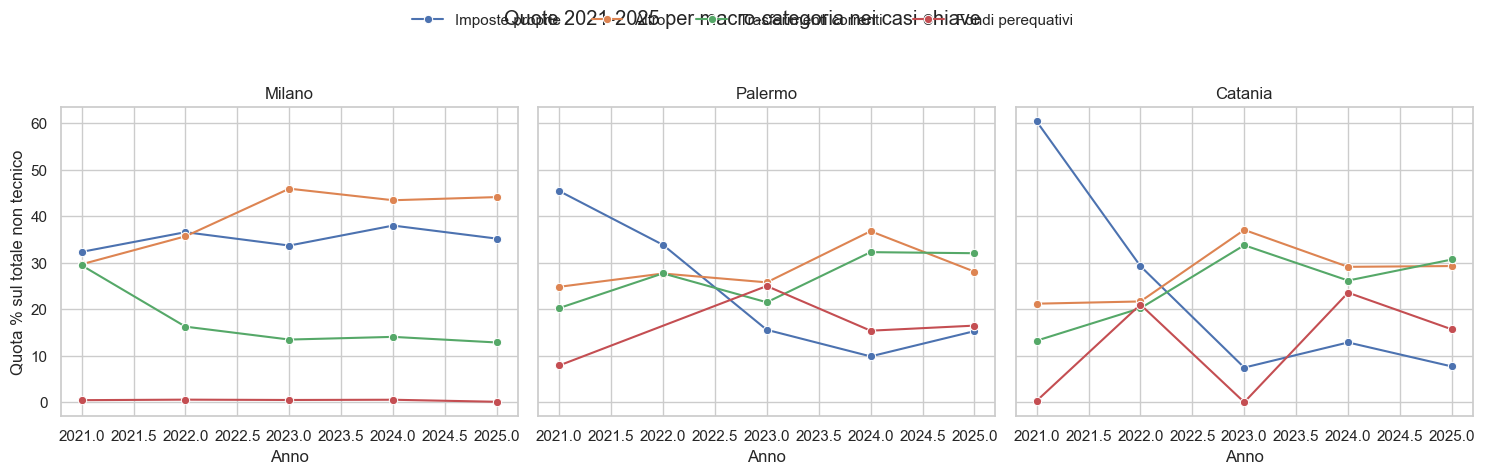

In [4]:
plot_df = quote_focus[quote_focus['macro_categoria_v2'].isin([
    'Imposte proprie',
    'Fondi perequativi',
    'Trasferimenti correnti',
    'Altro',
])].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, comune in zip(axes, ['Milano', 'Palermo', 'Catania']):
    subset = plot_df[plot_df['comune'] == comune]
    sns.lineplot(
        data=subset,
        x='anno',
        y='quota_pct',
        hue='macro_categoria_v2',
        marker='o',
        ax=ax,
    )
    ax.set_title(comune)
    ax.set_xlabel('Anno')
    ax.set_ylabel('Quota % sul totale non tecnico')
    ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
fig.suptitle('Quote 2021-2025 per macro-categoria nei casi chiave', y=1.05)
fig.tight_layout()
plt.show()

## 3. Segnali 2024 -> esito 2025

Trasformo i follow-up in una tabella semplice: il segnale letto nel `2024` regge anche nel `2025`, si attenua, o rientra?

In [5]:
signals = con.execute(
    '''
    with comuni as (
      select * from (values
        ('COMUNE DI MILANO', 'Milano'),
        ('COMUNE DI PALERMO', 'Palermo'),
        ('COMUNE DI CATANIA', 'Catania')
      ) as t(denominazione_ente, comune)
    ), base as (
      select c.comune, x.anno, x.macro_categoria_v2, sum(x.importo_totale_eur) as euro
      from read_parquet(?) x
      join comuni c using(denominazione_ente)
      where x.tipo_ente = 'COMUNE' and x.is_titolo_9 = false and x.anno in (2024, 2025)
      group by 1,2,3
    ), tot as (
      select comune, anno, sum(euro) as totale_eur
      from base
      group by 1,2
    ), quote as (
      select comune, anno, macro_categoria_v2,
             100.0 * euro / nullif(totale_eur, 0) as quota_pct
      from base join tot using(comune, anno)
    )
    select * from quote
    ''',
    [str(CROSS_PATH)],
).df()

pivot = signals.pivot_table(index=['comune', 'macro_categoria_v2'], columns='anno', values='quota_pct').reset_index()
pivot.columns = ['comune', 'macro_categoria_v2', 'quota_2024_pct', 'quota_2025_pct']
pivot['delta_pp'] = (pivot['quota_2025_pct'] - pivot['quota_2024_pct']).round(2)

focus_rows = pivot[
    ((pivot['comune'] == 'Milano') & (pivot['macro_categoria_v2'].isin(['Imposte proprie', 'Altro'])))
    | ((pivot['comune'] == 'Palermo') & (pivot['macro_categoria_v2'].isin(['Trasferimenti correnti', 'Fondi perequativi'])))
    | ((pivot['comune'] == 'Catania') & (pivot['macro_categoria_v2'].isin(['Fondi perequativi', 'Trasferimenti correnti'])))
].copy()

focus_rows['esito_2025'] = focus_rows['delta_pp'].apply(
    lambda x: 'quasi stabile' if abs(x) < 1 else ('in crescita' if x > 0 else 'in calo')
)

focus_rows.sort_values(['comune', 'macro_categoria_v2'])

,comune,macro_categoria_v2,quota_2024_pct,quota_2025_pct,delta_pp,esito_2025
2,Catania,Fondi perequativi,23.58,15.68,-7.90,in calo
4,Catania,Trasferimenti correnti,26.19,30.72,4.53,in crescita
5,Milano,Altro,43.47,44.15,0.68,quasi stabile
8,Milano,Imposte proprie,38.02,35.21,-2.81,in calo
12,Palermo,Fondi perequativi,15.40,16.49,1.09,in crescita
14,Palermo,Trasferimenti correnti,36.81,28.11,-8.70,in calo


## 4. Dentro `Altro`: Milano e Firenze

Qui il punto non e' eliminare `Altro`, ma capire che cosa lo sostiene davvero nei due casi piu pesanti. Uso il `2025` come fotografia finale, dopo aver verificato la persistenza del peso nel tempo.

In [6]:
altro_2025 = con.execute(
    '''
    with comuni as (
      select * from (values
        ('COMUNE DI MILANO', 'Milano'),
        ('COMUNE DI FIRENZE', 'Firenze')
      ) as t(denominazione_ente, comune)
    ), altro as (
      select c.comune, x.anno, sum(x.importo_totale_eur) as totale_altro_eur
      from read_parquet(?) x
      join comuni c using(denominazione_ente)
      where x.tipo_ente = 'COMUNE'
        and x.is_titolo_9 = false
        and x.macro_categoria_v2 = 'Altro'
        and x.anno = 2025
      group by 1,2
    ), dettaglio as (
      select c.comune, x.anno, x.codice_voce, x.descrizione_codice, sum(x.importo_totale_eur) as euro
      from read_parquet(?) x
      join comuni c using(denominazione_ente)
      where x.tipo_ente = 'COMUNE'
        and x.is_titolo_9 = false
        and x.macro_categoria_v2 = 'Altro'
        and x.anno = 2025
      group by 1,2,3,4
    )
    select
      d.comune,
      d.codice_voce,
      d.descrizione_codice,
      round(d.euro, 2) as euro,
      round(100.0 * d.euro / nullif(a.totale_altro_eur, 0), 2) as quota_su_altro_pct
    from dettaglio d
    join altro a using(comune, anno)
    qualify row_number() over(partition by d.comune order by d.euro desc) <= 8
    order by 1, 4 desc
    ''',
    [str(CROSS_PATH), str(CROSS_PATH)],
).df()

altro_2025

,comune,codice_voce,descrizione_codice,euro,quota_su_altro_pct
0,Firenze,3.02.02.01.004,Proventi da multe e sanzioni per violazioni de...,"73,265,469.70",22.64
1,Firenze,3.01.03.01.002,Canone occupazione spazi e aree pubbliche,"37,766,473.85",11.67
2,Firenze,6.03.01.04.999,Accensione mutui e altri finanziamenti a medio...,"34,131,691.52",10.55
3,Firenze,3.01.03.02.002,Locazioni di altri beni immobili,"25,188,721.78",7.78
4,Firenze,3.04.02.03.002,Entrate derivanti dalla distribuzione di divid...,"23,920,812.34",7.39
5,Firenze,3.01.02.01.035,Proventi da autorizzazioni,"16,344,802.57",5.05
6,Firenze,4.05.01.01.001,Permessi di costruire,"16,155,792.44",4.99
7,Firenze,3.02.02.99.001,Altre entrate derivanti dall'attivita' di cont...,"13,876,693.04",4.29
8,Milano,3.01.02.01.043,Proventi per traffico e trasporto passeggeri e...,"386,105,517.23",20.18
9,Milano,3.02.02.01.004,Proventi da multe e sanzioni per violazioni de...,"178,594,258.54",9.34


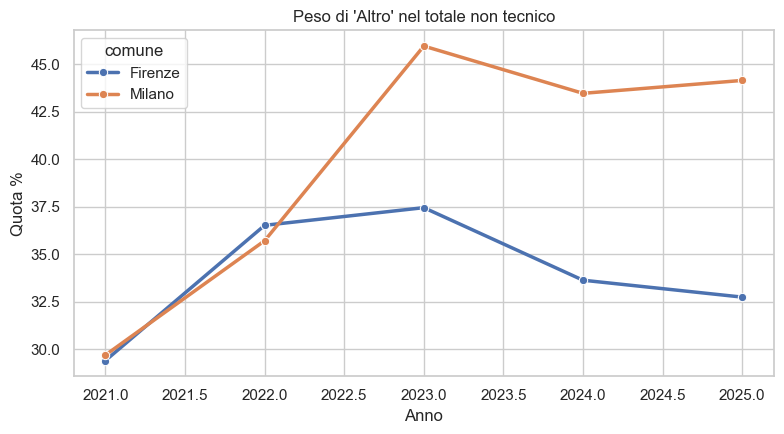

In [7]:
quote_altro = con.execute(
    '''
    with comuni as (
      select * from (values
        ('COMUNE DI MILANO', 'Milano'),
        ('COMUNE DI FIRENZE', 'Firenze')
      ) as t(denominazione_ente, comune)
    ), base as (
      select c.comune, x.anno, sum(x.importo_totale_eur) as euro_altro
      from read_parquet(?) x
      join comuni c using(denominazione_ente)
      where x.tipo_ente = 'COMUNE'
        and x.is_titolo_9 = false
        and x.macro_categoria_v2 = 'Altro'
      group by 1,2
    ), tot as (
      select c.comune, x.anno, sum(x.importo_totale_eur) as totale_eur
      from read_parquet(?) x
      join comuni c using(denominazione_ente)
      where x.tipo_ente = 'COMUNE'
        and x.is_titolo_9 = false
      group by 1,2
    )
    select b.comune, b.anno, round(100.0 * b.euro_altro / nullif(t.totale_eur, 0), 2) as quota_pct
    from base b join tot t using(comune, anno)
    order by 1,2
    ''',
    [str(CROSS_PATH), str(CROSS_PATH)],
).df()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=quote_altro, x='anno', y='quota_pct', hue='comune', marker='o', linewidth=2.5, ax=ax)
ax.set_title("Peso di 'Altro' nel totale non tecnico")
ax.set_xlabel('Anno')
ax.set_ylabel('Quota %')
plt.tight_layout()
plt.show()

## 5. Sintesi operativa

Il `2025` non smentisce i pattern principali emersi nei follow-up precedenti; li rende piu leggibili su una finestra a 5 anni.

- `Milano`: `Altro` resta strutturalmente molto alto anche nel `2025`, sostenuto soprattutto da trasporti, multe, locazioni e altre entrate correnti.
- `Catania`: il picco dei `Fondi perequativi` nel `2024` rientra nel `2025`, ma non torna al livello quasi nullo del `2023`.
- `Palermo`: il riequilibrio tra `Trasferimenti correnti` e `Fondi perequativi` va letto su una serie piu lunga, non come singolo scambio 2024-2025.
- `Firenze`: `Altro` resta alto ma piu leggibile una volta scomposto tra multe, COSAP/canoni, mutui e altre voci extra-tributarie.

Questo notebook chiude il primo vero uso del `cross_year` `2021-2025` per `entrate / comuni` e lascia aperto il passo successivo naturale: decidere se tenere `d3` come follow-up interno o estrarne un commento pubblico piu corto.
